# 01 — Data Understanding (FD001)

**Phase 3 — FD001 Exploration**

Goals of this notebook:
- Load the raw FD001 train/test/RUL files via `src.data.ingestion`
- Assign the correct 26-column schema
- Get a first look at shape, engines, and cycle ranges

> **Prerequisite:** place the NASA C-MAPSS files inside `data/raw/CMAPSS/` before running this notebook:
> `train_FD001.txt`, `test_FD001.txt`, `RUL_FD001.txt`

In [1]:
import sys
sys.path.append('..')  # so `src` is importable from notebooks/

import pandas as pd
import matplotlib.pyplot as plt

from src.data.ingestion import DataIngestion
from src.data.validation import DataValidation
from src.entity.config_entity import DataIngestionConfig, DataValidationConfig
from src.config.config import DATASET_VARIANTS

pd.set_option('display.max_columns', 30)

Matplotlib is building the font cache; this may take a moment.


## Load FD001

In [2]:
VARIANT = 'FD001'

ingestion_cfg = DataIngestionConfig(variant=VARIANT)
ingestion = DataIngestion(ingestion_cfg)

data = ingestion.run(persist=True)
train_df, test_df, rul_df = data['train'], data['test'], data['rul']

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('RUL shape  :', rul_df.shape)

[2026-08-27 21:53:12] INFO     | src.data.ingestion | Loaded train_FD001.txt -> shape=(20631, 26), engines=100
[2026-08-27 21:53:12] INFO     | src.data.ingestion | Loaded test_FD001.txt -> shape=(13096, 26), engines=100
[2026-08-27 21:53:12] INFO     | src.data.ingestion | Loaded RUL_FD001.txt -> shape=(100, 2)
[2026-08-27 21:53:12] INFO     | src.data.ingestion | Persisted processed files for FD001 to /Users/jvpurushotham/Desktop/PrognosX/data/processed
Train shape: (20631, 26)
Test shape : (13096, 26)
RUL shape  : (100, 2)


In [3]:
train_df.head()

,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Dataset metadata sanity check
Confirm the loaded data matches the documented FD001 characteristics (100 train engines, 100 test engines, 1 operating condition, 1 fault mode).

In [4]:
print(DATASET_VARIANTS[VARIANT])

print('Train engines found:', train_df['unit_number'].nunique())
print('Test engines found :', test_df['unit_number'].nunique())

{'train_engines': 100, 'test_engines': 100, 'operating_conditions': 1, 'fault_modes': 1, 'description': '1 operating condition, 1 fault mode (HPC degradation)'}
Train engines found: 100
Test engines found : 100


## Cycle range per engine (train)

In [5]:
cycle_summary = train_df.groupby('unit_number')['time_in_cycles'].max()
cycle_summary.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64

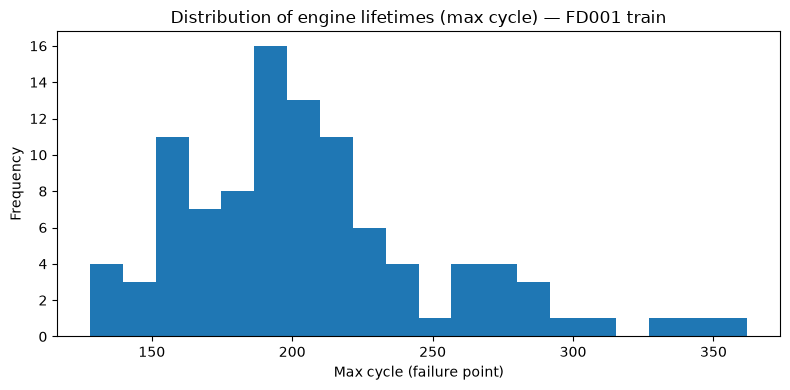

In [6]:
cycle_summary.plot(kind='hist', bins=20, figsize=(8, 4), 
                    title='Distribution of engine lifetimes (max cycle) — FD001 train')
plt.xlabel('Max cycle (failure point)')
plt.tight_layout()
plt.show()

## Run structural validation
Runs the checks defined in `src/data/validation.py`: missing values, duplicates, dtypes, engine IDs, cycle ordering, constant sensors.

In [7]:
validation_cfg = DataValidationConfig(variant=VARIANT)
validator = DataValidation(validation_cfg)

train_report = validator.validate(train_df, dataset_name='train')
validator.save_report(train_report, suffix='train')

test_report = validator.validate(test_df, dataset_name='test')
validator.save_report(test_report, suffix='test')

import json
print(json.dumps(train_report, indent=2, default=str))

[2026-08-27 21:54:15] INFO     | src.data.validation | Validation for FD001 [train]: passed=True, engines=100, constant_sensors=['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
[2026-08-27 21:54:15] INFO     | src.data.validation | Validation report saved to /Users/jvpurushotham/Desktop/PrognosX/data/processed/validation_report_FD001_train.json
[2026-08-27 21:54:15] INFO     | src.data.validation | Validation for FD001 [test]: passed=True, engines=100, constant_sensors=['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
[2026-08-27 21:54:15] INFO     | src.data.validation | Validation report saved to /Users/jvpurushotham/Desktop/PrognosX/data/processed/validation_report_FD001_test.json
{
  "dataset": "train",
  "variant": "FD001",
  "schema_ok": true,
  "missing_columns": [],
  "extra_columns": [],
  "has_missing_values": false,
  "missing_value_columns": {},
  "duplicate_engine_cycle_rows": 0,
  "dtypes": {
    "unit_number": "int64

## Next
Continue to **02_eda.ipynb** for general exploratory data analysis, then **03_sensor_analysis.ipynb** for sensor-level degradation analysis.